In [1]:
# %pip install torch_geometric
# %pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.4.0+cu121.html

In [2]:
import DeviceDir
import torch

DIR, RESULTS_DIR = DeviceDir.get_directory()
device, NUM_PROCESSORS = DeviceDir.get_device()

# device = torch.device("cpu")

# device

In [3]:
DIR

'/scratch/gilbreth/das90/Dataset/'

In [4]:
import torch
from contextlib import contextmanager
import subprocess
import re

# # At the start of your script
# torch.cuda.reset_peak_memory_stats()  # Reset memory statistics

# # ... your training loop ...

# # Get max memory used (in bytes)
# max_memory = torch.cuda.max_memory_allocated()
# print(f"Max GPU memory used: {max_memory / 1024**2:.2f} MB")

# # Optionally, get memory by device if using multiple GPUs
# for i in range(torch.cuda.device_count()):
#     max_memory = torch.cuda.max_memory_allocated(i)
#     print(f"Max GPU memory used on device {i}: {max_memory / 1024**2:.2f} MB")


# @contextmanager
# def track_memory_usage(description="", device=None):
#     if device is None:
#         device = torch.cuda.current_device()
#     torch.cuda.synchronize(device)
#     torch.cuda.reset_peak_memory_stats(device)
#     yield
#     torch.cuda.synchronize(device)
#     max_memory = torch.cuda.max_memory_allocated(device)
#     print(f"{description} Max GPU memory used: {max_memory / 1024**2:.2f} MB")
    
def get_gpu_memory_usage():
    result = subprocess.check_output(['nvidia-smi', '--query-gpu=memory.used', '--format=csv,nounits,noheader'])
    memory_usage = [int(x) for x in result.decode('utf-8').strip().split('\n')]
    return memory_usage

# Call this periodically during training to track memory usage
get_gpu_memory_usage()

[425]

In [5]:
import os
import torch
import random
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid, Reddit
from torch_geometric.nn import GCNConv
from torch_geometric.loader import ClusterData, ClusterLoader
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt
import time
from torch_geometric.datasets import WikipediaNetwork
from sklearn.model_selection import train_test_split
from torch_geometric.typing import Adj, SparseTensor
from ogb.nodeproppred import Evaluator, PygNodePropPredDataset
from torch_geometric.utils import scatter
from torch_geometric.datasets import Reddit, Reddit2, Flickr, Yelp, AmazonProducts, PPI,  OGB_MAG,  FakeDataset, Amazon,Coauthor,HeterophilousGraphDataset, CitationFull
from torch_geometric.utils import homophily
from torch_geometric.utils import negative_sampling
from torch_geometric.utils import add_random_edge

def fix_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fix_seeds()

In [6]:
all_dataset = [
    "Cornell",
    "Texas",
    "Wisconsin",
    "reed98",
    "amherst41",
    "penn94",
    "Roman-empire",
    "cornell5",
    "Squirrel",
    "johnshopkins55",
    "Actor",
    "Minesweeper",
    "Questions",
    "Chameleon",
    "Tolokers",
    "Amazon-ratings",
    "genius",
    "pokec",
    "arxiv-year",
    "snap-patents",
    "ogbn-proteins",
    "Cora",
    "DBLP",
    "Computers",
    "PubMed",
    "Cora_ML",
    "SmallCora",
    "CS",
    "Photo",
    "Physics",
    "CiteSeer",
    "wiki",
    "Reddit"
]

In [7]:
from ipynb.fs.full.SGSLoadDataset import LOAD_DATASET

DATASET_NAME = "arxiv-year"
data, dataset  = LOAD_DATASET(DIR, DATASET_NAME)
num_classes = max(data.y).item()+1

arxiv-year N: 169343 E: 2315598 F: 128 C: 5 d: 13.67 lr: 0.60 i: False s: False u: True


In [8]:
structure = False

In [9]:
He = homophily(data.edge_index, data.y, method='edge')
print("Edge Homophily: ", He)

Edge Homophily:  0.21815098822116852


In [10]:
from torch_geometric.nn import GCNConv, GATConv, GINConv, SAGEConv, ChebConv, GAT, GIN
from torch_geometric.utils import to_scipy_sparse_matrix, add_self_loops, degree, normalized_cut
from torch_sparse import SparseTensor
from torch_scatter import scatter_add

In [11]:
# --- 3. Define a simple two-layer GCN using manual spmm and ddmm steps ---
class ManualGCN(torch.nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super().__init__()
        self.W1 = torch.nn.Parameter(torch.randn(in_feats, hidden_feats))
        self.W2 = torch.nn.Parameter(torch.randn(hidden_feats, out_feats))
        # Initialize weights (optional but recommended)
        torch.nn.init.xavier_uniform_(self.W1)
        torch.nn.init.xavier_uniform_(self.W2)

    def forward(self, x, A_sparse):
        # Layer 1: X' = ReLU( A_hat @ X @ W1 )
        #  3.1 Sparse‐Dense multiply: support1 = A_hat @ X
        support1 = torch.sparse.mm(A_sparse, x)
        #  3.2 Dense‐Dense multiply: hidden = support1 @ W1
        hidden = support1 @ self.W1
        hidden = F.relu(hidden)

        # Layer 2: X'' = A_hat @ hidden @ W2, followed by log_softmax
        support2 = torch.sparse.mm(A_sparse, hidden)
        out_logits = support2 @ self.W2
        return F.log_softmax(out_logits, dim=1)

# --- 4. Set up timing instrumentation ---
# Global accumulators for time spent in different categories:
time_spmm = 0.0      # sparse‐dense matrix multiply
time_ddmm = 0.0      # dense‐dense matrix multiply
time_total = 0.0     # total forward time

# Keep references to the original functions
_original_sparse_mm = torch.sparse.mm
_original_matmul = torch.Tensor.__matmul__  # the "@" operator is Tensor.__matmul__

# Define wrapped versions
def _timed_sparse_mm(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    global time_spmm
    t0 = time.time()
    res = _original_sparse_mm(a, b)
    t1 = time.time()
    time_spmm += (t1 - t0)
    return res

def _timed_matmul(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    global time_ddmm
    t0 = time.time()
    res = _original_matmul(a, b)
    t1 = time.time()
    time_ddmm += (t1 - t0)
    return res

# Monkey‐patch the functions
torch.sparse.mm = _timed_sparse_mm
torch.Tensor.__matmul__ = _timed_matmul

In [12]:
class EdgeProbMLP(nn.Module):
    def __init__(self, in_channels, hidden_dim, dropout_prob=0.2):
        super(EdgeProbMLP, self).__init__()
#         self.gcn1 = GCNConv(in_channels, hidden_dim) #sample 1 hop neighborhood
        self.dropout = nn.Dropout(dropout_prob)
#         self.gcn2 = GCNConv(hidden_dim, hidden_dim) #sample 2 hop neighborhood
        
        self.fc_dim = nn.Linear(in_channels, hidden_dim)
#         self.dropout = nn.Dropout(dropout_prob)

        self.fc1 = nn.Linear(2 * hidden_dim, hidden_dim)
        
        # self.fc_residual = nn.Linear(2 * hidden_dim, hidden_dim)  # For residual connection
        # self.fc1 = nn.Linear(2 * in_channels, hidden_dim) #if straightforward link
        
        # self.dropout = nn.Dropout(dropout_prob)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, node_features, edge_index):

#         out = F.relu(self.gcn1(node_features, edge_index))
#         out = self.dropout(out)
# #         out = F.relu(self.gcn2(out, edge_index))
        
#         x = out[edge_index[0]]
#         y = out[edge_index[1]]
        
        x = self.dropout(F.relu(self.fc_dim(node_features[edge_index[0]])))
        y = self.dropout(F.relu(self.fc_dim(node_features[edge_index[1]])))

        edge_features = torch.cat([x*y,x-y], dim=1) #x*y|x-y
        x = F.relu(self.fc1(edge_features))
        # x = x + self.fc_residual(edge_features) #  # Add residual connection
        x = self.dropout(x)
        prob = torch.sigmoid(self.fc2(x))
        # prob.requires_grad_(True)
        return prob
    

In [13]:
class GINModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_dim, out_channels, num_classes, dropout_prob=0.2):
        super(GINModel, self).__init__()
        self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim, dropout_prob)        
        self.dropout_prob = dropout_prob
        self.GIN = GIN(in_channels = in_channels,
                        hidden_channels = hidden_dim, 
                        num_layers = 2, out_channels = num_classes,
                        dropout = dropout_prob, 
                        act = 'relu')
                    
        
    def forward(self, data, edge_index, edge_weight=None):
        x = self.GIN(data.x, edge_index, edge_weight=edge_weight)
        return x

In [14]:
class GATModel(torch.nn.Module):        
    def __init__(self, in_channels, hidden_dim, out_channels, num_classes, dropout_prob=0.2, heads=8):
        super(GATModel, self).__init__()
        self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim, dropout_prob)        
        self.dropout_prob = dropout_prob
        
        self.GAT =  GAT(in_channels = in_channels,
                        hidden_channels = hidden_dim, 
                        num_layers = 2, out_channels = num_classes,
                        dropout = dropout_prob, 
                        act = 'relu')
        
    def forward(self, data, edge_index, edge_weight=None):
        x = self.GAT(data.x, edge_index, edge_weight=edge_weight)        
        return x

In [15]:
class ChebModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_channels, num_classes, dropout_prob=0.3):
        super(ChebModel, self).__init__()
        self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim, dropout_prob)
        self.dropout_prob = dropout_prob
        
        self.gcn1 = ChebConv(in_channels, hidden_dim, K=1, normalization='sym')
        self.dropout = nn.Dropout(dropout_prob)
        self.gcn2 = ChebConv(hidden_dim, num_classes, K=1, normalization='sym')

    def forward(self, data, edge_index, edge_weight=None):
        x = F.relu(self.gcn1(data.x, edge_index, edge_weight))
        x = self.dropout(x)
        out = self.gcn2(x, edge_index, edge_weight)
        return out

In [16]:
class GNNModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_channels, num_classes, dropout_prob=0.3):
        super(GNNModel, self).__init__()
        self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim, dropout_prob)
        # self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim)
        self.gcn1 = GCNConv(in_channels, hidden_dim)
        self.dropout = nn.Dropout(dropout_prob)
        self.gcn2 = GCNConv(hidden_dim, num_classes)

    def forward(self, data, edge_index, edge_weight=None):
        x = F.relu(self.gcn1(data.x, edge_index, edge_weight))
        x = self.dropout(x)
        out = self.gcn2(x, edge_index, edge_weight)
        return out

In [17]:
# def getSparse(batch, edge_index, edge_weight  = None):
#     num_nodes = batch.num_nodes
#     edge_index_with_loops, _ = add_self_loops(edge_index, num_nodes=num_nodes)

#     row, col = edge_index_with_loops
#     deg = degree(col, num_nodes=num_nodes, dtype=torch.float32)  # degree of each node (including self‐loops)
#     deg_inv_sqrt = deg.pow(-0.5)
#     deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0

#     norm_values = deg_inv_sqrt[row] * deg_inv_sqrt[col]

#     # Create a sparse tensor A_hat in COO format
#     A_Sparse = torch.sparse_coo_tensor(
#         indices=torch.stack([row, col], dim=0),
#         values=norm_values,
#         size=(num_nodes, num_nodes)
#     ).coalesce()#.to(device)  # keep on CPU or move to GPU later if desired
    
#     return A_Sparse

def getSparse(batch, edge_index, edge_weight=None):

    num_nodes = batch.num_nodes

    if edge_weight is not None:
        # Add self-loops to edge_index and edge_weight
#         edge_index_with_loops, edge_weight_with_loops = add_self_loops(
#             edge_index, edge_attr=edge_weight, num_nodes=num_nodes
#         )

        edge_index_with_loops = edge_index
        edge_weight_with_loops = edge_weight

        row, col = edge_index_with_loops
        # Compute weighted degree
        deg = scatter_add(edge_weight_with_loops, col, dim=0, dim_size=num_nodes)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0

        # Normalize edge weights
        norm_values = deg_inv_sqrt[row] * edge_weight_with_loops * deg_inv_sqrt[col]
    else:
        # Add self-loops without edge weights
        #edge_index_with_loops, _ = add_self_loops(edge_index, num_nodes=num_nodes)
        edge_index_with_loops = edge_index
        row, col = edge_index_with_loops

        deg = degree(col, num_nodes=num_nodes, dtype=torch.float32)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0

        norm_values = deg_inv_sqrt[row] * deg_inv_sqrt[col]

    # Create a sparse tensor A_hat in COO format
    A_Sparse = torch.sparse_coo_tensor(
        indices=torch.stack([row, col], dim=0),
        values=norm_values,
        size=(num_nodes, num_nodes)
    ).coalesce().to(device)
    
    print(A_Sparse._nnz())  # Correct method for COO format

    return A_Sparse


class CustomGNNModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_channels, num_classes, dropout_prob=0.3):
        super(CustomGNNModel, self).__init__()
        self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim, dropout_prob)
        # self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim)
        self.gcn1 = ManualGCN(in_channels, hidden_dim, num_classes)
    

    
    def forward(self, batch, A_Sparse):
        return self.gcn1(batch.x, A_Sparse)
    
    
#     def forward(self, batch, edge_index, edge_weight = None):
#         A_Sparse = getSparse(batch, edge_index, edge_weight)
        
#         return self.gcn1(batch.x, A_Sparse)
    

In [18]:
# model = GATModel(in_channels=data.x.shape[1], hidden_dim=16, out_channels=0, num_classes=dataset.num_classes, dropout_prob=0.3)

# for name, param in model.named_parameters():
#     print(name)
#     if 'GAT' in name or 'gcn' in name:
#         print("->>",name)

In [19]:
import os
data

Data(x=[169343, 128], edge_index=[2, 2315598], y=[169343], train_mask=[169343], val_mask=[169343], test_mask=[169343])

In [20]:
plt.rcParams['text.usetex'] = True

def plot_probs(edge_probs,sampling_probs):
    ep = edge_probs.detach().cpu().numpy()
    sp = sampling_probs.detach().cpu().numpy()
    
    plt.figure(figsize=(20, 6))    
    plt.subplot(2, 1, 1)

    #plt.plot(ep)
    plt.scatter(range(len(ep)), ep, s=2)
    plt.title('Curve of Edge Probs')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.grid(True)

    plt.subplot(2, 1, 2)
    #plt.plot(sp)
    plt.scatter(range(len(sp)), sp, s=2)
    plt.title('Curve of Samples Probs')
    plt.xlabel('Index')
    plt.ylabel('Probability')
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
    
def plot_hist(edge_probs,sampling_probs, ep_select, sp_select, isprior=False):
    
    sp = sampling_probs.detach().cpu().numpy()
    if edge_probs is not None:
        ep = edge_probs.detach().cpu().numpy()
    
    if ep_select is not None and sp_select is not None:        
        ep_select = ep_select.detach().cpu().numpy()
        sp_select = sp_select.detach().cpu().numpy()
    
    fig = plt.figure(figsize=(20, 10))    
    ax = fig.add_subplot(111)
    
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    fontsize = 32
    
        
#     if edge_probs is not None:
#         plt.subplot(2, 1, 1)
#         #plt.plot(ep)
#         plt.hist(ep, bins= 30, edgecolor='black')
#         plt.title('Histogram of edge weight ($w$)')
#         plt.xlabel('Edge weight ($w$)')
#         plt.ylabel('Count')
#         plt.grid(True)
    
#     if edge_probs is not None:
#         plt.subplot(2, 1, 2)
#     else:
#         plt.subplot(2, 1, 1)
    #plt.plot(sp)
    plt.hist(sp, bins= 30, edgecolor='black')
    
    plt.xticks(fontname="Times New Roman", fontsize=fontsize)
    plt.yticks(fontname="Times New Roman", fontsize=fontsize)
    
#     if isprior:
#         plt.title(r'Histogram of prior probability distribution ($p_\mathrm{prior}$)', fontname="Times New Roman", fontsize=fontsize)
#         plt.xlabel(r'Probability ($p_\mathrm{prior}$)', fontname="Times New Roman", fontsize=fontsize)
#     else:
#         plt.title(r'Histogram of learned probability distribution ($\tilde{p}$)', fontname="Times New Roman", fontsize=fontsize)
#         plt.xlabel(r'Probability $\tilde{p}$', fontname="Times New Roman", fontsize=fontsize)
    
    # augmented
    if isprior:
        plt.title(r'Histogram of prior probability distribution ($p_\mathrm{prior}$)', fontname="Times New Roman", fontsize=fontsize)
        plt.xlabel(r'Probability ($p_\mathrm{prior}$)', fontname="Times New Roman", fontsize=fontsize)
    else:
        plt.title(r'Histogram of augmented learned probability distribution ($\tilde{p}_a$)', fontname="Times New Roman", fontsize=fontsize)
        plt.xlabel(r'Probability $\tilde{p}_a$', fontname="Times New Roman", fontsize=fontsize)
    
    
    
    plt.ylabel('Count', fontname="Times New Roman", fontsize=fontsize)
    
    plt.grid(False)

#     plt.subplot(4, 1, 3)
#     #plt.plot(sp)
#     plt.hist(ep_select, bins= 30, edgecolor='black')
#     plt.title('histogram of selected Edge Probs')
#     plt.xlabel('Index')
#     plt.ylabel('Probability')
#     plt.grid(True)
    
#     plt.subplot(4, 1, 4)
#     #plt.plot(sp)
#     plt.hist(sp_select, bins= 30, edgecolor='black')
#     plt.title('histogram of selected sampled Probs')
#     plt.xlabel('Index')
#     plt.ylabel('Probability')
#     plt.grid(True)

    
    plt.tight_layout()
    
    output_dir = "DistFigures/"
    os.makedirs(output_dir, exist_ok=True)
        
    if isprior == False:        
        filename = os.path.join(output_dir, "SGS-learnedp_a.pdf")
    else:
        filename = os.path.join(output_dir, "SGS-prior.pdf")
    
    fig.savefig(filename, format="pdf", bbox_inches="tight")
    
    plt.show()

In [21]:
from torch_geometric.utils import to_scipy_sparse_matrix
import scipy.sparse as sp

In [22]:
# Gumbel-Softmax trick for edge sampling
def gumbel_softmax_sampling(batch, edge_probs, edge_index, q=500, temperature=1.0, log=False, istest=False, epoch=-1):
        
    if istest:
        # samples = torch.exp(edge_probs)/torch.exp(edge_probs).sum()
        samples = edge_probs/edge_probs.sum()
        #samples = 0.7 * samples + 0.3*batch.prob #temporary
#         top_k_values, sampled_edges = torch.topk(samples, q, dim=-1, largest=True, sorted=True)
        #sampled_edges = torch.multinomial(samples, q, replacement=False) #nothing
        
#         samples = F.softmax(edge_probs/temperature, dim=-1)
        sampled_edges = torch.multinomial(samples, q, replacement=False) #nothing
#         top_k_values, sampled_edges = torch.topk(edge_probs, q, dim=-1, largest=True, sorted=True)
        # edge_gradients = edge_probs.grad
        # sampled_edges = torch.topk(edge_gradients.abs(),k=q)
    else:
        # warmup_epochs = 20  # Number of epochs for the warm-up phase
        # if epoch< warmup_epochs:
            # samples = F.softmax(batch.prob, dim=-1)
            # sampled_edges = torch.multinomial(samples, q, replacement=False) #nothing               
        # else:
#         samples = torch.exp(edge_probs)/torch.exp(edge_probs).sum()
        # edge_probs += torch.ones_like(edge_probs)/len(edge_probs)
        samples =  edge_probs/edge_probs.sum()
        
#         print(edge_probs)
#         print(torch.sum(edge_probs))
#         print(torch.sum(samples))
        
#         samples = F.softmax(edge_probs/temperature, dim=-1)
#         samples = 0.1*samples + 0.9*torch.rand_like(samples)
#         samples = 0.7 * samples + 0.3*batch.prob    
        sampled_edges = torch.multinomial(samples, q, replacement=False) #nothing
#         gumbels = -torch.empty_like(edge_probs).exponential_().log()
#         gumbels = (gumbels - gumbels.min()) / (gumbels.max() - gumbels.min())
        
#         #noise = 1.0 + (epoch/100)*9.0
#         noise = 1.0
        
#         gumbels = gumbels/noise
        
    
# #         gumbels = 0

#         logits = (edge_probs + gumbels) / temperature    
#         samples = F.softmax(logits, dim=-1)

#         top_k_values, sampled_edges = torch.topk(samples, q, dim=-1, largest=True, sorted=True) # 50       
        
    
        #print(f'{torch.mean(samples).item():.4f}, {torch.var(samples).item():.4f}, {torch.std(samples).item():.4f}')    
        #print("EP: ",torch.mean(edge_probs).item(), torch.var(edge_probs).item())
        #print("SP: ",torch.mean(samples).item(), torch.var(samples).item())
    
#     print("Test" if istest == True else "Train")
    
#     if epoch%10 == 0:    
#         print("Epoch :", epoch, end="-------->")        
#     #     print(edge_probs)
#     #     print(samples)   
#     #         #plot_probs(edge_probs, samples)
#         plot_hist(edge_probs, samples, edge_probs[sampled_edges],samples[sampled_edges])

# #         adj = to_scipy_sparse_matrix(data.edge_index[:,sampled_edges], num_nodes=data.num_nodes)
# #         num_components, component = sp.csgraph.connected_components(adj, connection='weak')
# #         print("Components: ", num_components)
    
# #     sampled_edges = torch.multinomial(samples, q, replacement=False)
# #     top_k_values, sampled_edges = torch.topk(edge_probs, q, dim=-1, largest=True, sorted=True)    

    
    one_hot = torch.zeros_like(samples)
    one_hot.scatter_(0, sampled_edges, 1.0)     
    
    indexs = (one_hot - samples).detach() + samples
    
    edge_probs = edge_probs*indexs
    indexs = indexs.bool()
    
    
#     if log:        
#         print("edge_probs: ",edge_probs)
# #         print("gumbels: ", gumbels)
# #         print("logits: ",logits)
#         print("samples: ",samples)
#         print("sampled_edges: ",sampled_edges)
#         print("One hot: ", one_hot)
#         print("Indexs: ",indexs)
#         print("edge_probs[indexs]:", edge_probs[indexs])

    
#     return indexs, edge_probs[indexs]
    
    return indexs, edge_probs[indexs]+0.01
    #return indexs, torch.clamp(edge_probs[indexs]+10, max=1.0)


# Random edge sampling
def random_edge_sampling(edge_index, q):
    num_edges = edge_index.shape[1]
    sampled_indices = torch.randperm(num_edges)[:q]
    sampled_edge_index = edge_index[:, sampled_indices]
    return sampled_edge_index

# F1 score calculation helper
def calculate_f1(logits, labels, mask):
    preds = logits[mask].argmax(dim=1)
    f1 = f1_score(labels[mask].cpu(), preds.cpu(), average='micro')
    return f1

def compute_node_similarity(node_embeddings):
    """
    Compute pairwise node similarity using cosine similarity.
    Args:
        node_embeddings (torch.Tensor): Node embeddings, shape [num_nodes, embedding_dim].
    Returns:
        torch.Tensor: Pairwise similarity matrix, shape [num_nodes, num_nodes].
    """
    similarity_matrix = F.cosine_similarity(
        node_embeddings.unsqueeze(1), node_embeddings.unsqueeze(0), dim=-1
    )
    return similarity_matrix

def consistency_loss(edge_probs, edge_indices, node_embeddings):
    """
    Consistency loss to align edge probabilities with global node similarity.
    Args:
        edge_probs (torch.Tensor): Predicted edge probabilities, shape [num_edges].
        edge_indices (torch.Tensor): Indices of edges, shape [2, num_edges].
        node_embeddings (torch.Tensor): Node embeddings, shape [num_nodes, embedding_dim].
    Returns:
        torch.Tensor: Consistency loss.
    """
    # print(edge_indices.shape)
    # Compute similarity matrix
    # similarity_matrix = compute_node_similarity(node_embeddings)
    
    # Extract similarities for given edges
    src, dst = edge_indices  # Split edge indices into source and destination
    # edge_similarities = similarity_matrix[src, dst]
    src_embeddings = node_embeddings[src]
    dst_embeddings = node_embeddings[dst]
    # Compute cosine similarity for edge pairs
    edge_similarities = F.cosine_similarity(src_embeddings, dst_embeddings, dim=-1)
    
    # Consistency loss as MSE between edge probabilities and node similarities
    loss = F.mse_loss(edge_probs[src], edge_similarities)
    return loss


# Training function with alternating updates
def train(epoch, max_epoch, model, optimizer_gnn, optimizer_edge_prob, optimizer, criterion, cluster_loader, device, q=500, mode='learned', alternate_frequency=1):
    model.train()
    total_loss = 0
    iteration = 0

    for batch in cluster_loader:
        if not batch.train_mask.any():
            continue

        batch = batch.to(device)
        
#         if alternate_frequency == 0:
#             update_gnn = True
#             update_edge_prob = True
#         else:            
#             # Decide if we are updating GNN or edge probability model
#             update_gnn = iteration % alternate_frequency == 0
#             update_edge_prob = not update_gnn
        # Zero gradients selectively        
#         if update_gnn:
#             optimizer_gnn.zero_grad()
#         if update_edge_prob:
#             optimizer_edge_prob.zero_grad()
        
        optimizer_edge_prob.zero_grad()
        optimizer_gnn.zero_grad()
        
        #optimizer.zero_grad()
        
        global time_total

        # Select edges based on mode
        if mode == 'learned':
                                                
            if batch.edge_index.shape[1] > q:
                
                edge_probs = model.edge_prob_mlp(batch.x, batch.edge_index).squeeze()   
                # edge_probs.retain_grad()
                # edge_probs.requires_grad = True                 
                # temperature = 2.0 - (epoch * (2 - 0.5) / max_epoch)
                # temperature = 1.0
                temperature = max(0.5, 0.7 - epoch*0.01) # Annealing (improves very little)
                #print(temperature)                
                sampled_edge_indices, sampled_edge_weight = gumbel_softmax_sampling(batch, edge_probs, batch.edge_index, q=q, temperature=temperature, log=(epoch==max_epoch-1),epoch=epoch)
                sampled_edge_index = batch.edge_index[:, sampled_edge_indices]      
                
                if model.__class__.__name__ == "CustomGNNModel":                    
                    A_Sparse = getSparse(batch, sampled_edge_index, sampled_edge_weight)
                    
                    t_start = time.time()
                    learned_out = model(batch, A_Sparse) 
                        
                else:
                    t_start = time.time()
                    learned_out = model(batch, sampled_edge_index, sampled_edge_weight) 
                t_end = time.time()
                time_total += (t_end - t_start)
                    
                    
#                 t_start = time.time()
#                 learned_out = model(batch, sampled_edge_index, sampled_edge_weight) 
#                 t_end = time.time()
#                 time_total += (t_end - t_start)

                     
                #out = model(batch, sampled_edge_index, None)     
                loss = criterion(learned_out[batch.train_mask], batch.y[batch.train_mask])
                loss.backward()
                optimizer_edge_prob.step()
                optimizer_gnn.step()
                    

#                 # random_edge_index = random_edge_sampling(batch.edge_index,q)
#                 # random_out = model(batch,random_edge_index)

#                 ###- firx prior---
#                 #with torch.no_grad():
#                 samples = F.softmax(batch.prob, dim=-1)
#                 edge_sample = torch.multinomial(samples, q, replacement=False) #nothing                
#                 sampled_edge_index = batch.edge_index[:,edge_sample]                
#                 random_out = model(batch,sampled_edge_index)

#                 # Calculate F1 scores for learned and random sampling
#                 learned_f1 = calculate_f1(learned_out, batch.y, batch.train_mask)
#                 random_f1 = calculate_f1(random_out, batch.y, batch.train_mask)
#                 # Compute loss for learned edges            

#                 if learned_f1 > random_f1:

#                     loss = criterion(learned_out[batch.train_mask], batch.y[batch.train_mask])


# #                     # Compute node classification loss
# #                     # loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
# #                     # loss = loss + 0.001 * torch.sum(torch.square(edge_probs))

#                     #######---regularizer 1
#                     edge_labels = torch.full((batch.edge_index.size(1),), -1, dtype=torch.long, device=device)
#                     train_indices = torch.nonzero(batch.train_mask).squeeze()
#                     train_edge_mask = torch.isin(batch.edge_index[0], train_indices) & torch.isin(batch.edge_index[1], train_indices)

#                     # Assign labels based on the class of the endpoints
#                     same_class_mask = batch.y[batch.edge_index[0]] == batch.y[batch.edge_index[1]]
#                     edge_labels[train_edge_mask & same_class_mask] = 1
#                     edge_labels[train_edge_mask & ~same_class_mask] = 0

#                     # Filter out the edges with labels -1
#                     valid_edge_mask = edge_labels != -1
#                     valid_edge_probs = edge_probs[valid_edge_mask]
#                     valid_edge_labels = edge_labels[valid_edge_mask]

#                     #print(torch.sum(valid_edge_labels))
#                     if torch.sum(valid_edge_labels).item() > 1:            
#                         loss2 = F.binary_cross_entropy(valid_edge_probs, valid_edge_labels.float().to(device))
#                     else:
#                         loss2 = 0

#                     loss = loss+loss2


#                     global_consistency_loss = consistency_loss(edge_probs,sampled_edge_index, learned_out)
#                     loss = loss + 0.5 *global_consistency_loss


    #     #             ########---regularizer 2

    #                 train_indices = torch.nonzero(batch.train_mask).squeeze()            
    #                 num_nodes = train_indices.size(0)
    #                 #num_edges = min(num_nodes*num_nodes,q)  # Adjust the number of edges as needed
    #                 num_edges = num_nodes*num_nodes

    #                 # Generate random edges
    #                 src = torch.randint(0, num_nodes, (num_edges,))
    #                 dst = torch.randint(0, num_nodes, (num_edges,))

    #                 # Map to actual node indices
    #                 src_nodes = train_indices[src]
    #                 dst_nodes = train_indices[dst]

    #                 # Create edge_index tensor
    #                 reg_edge_index = torch.stack([src_nodes, dst_nodes], dim=0).to(device)
    #                 reg_edge_label = (batch.y[src_nodes] == batch.y[dst_nodes]).float().to(device)            
    #                 reg_edge_probs = model.edge_prob_mlp(batch.x, reg_edge_index).squeeze()

    #                 loss4 = F.binary_cross_entropy(reg_edge_probs, reg_edge_label)

    #                 #print(reg_edge_index)
    #                 #print(reg_edge_label)

    #                 loss = loss+loss4




#                     loss.backward()
#                     optimizer_edge_prob.step()
#                     optimizer_gnn.step()
#                     #optimizer.step()                
#                     #print("learned..")
#                 else:
#                     loss = criterion(random_out[batch.train_mask], batch.y[batch.train_mask])
#                     loss.backward()
#                     optimizer_gnn.step()
#                     #optimizer.zero_grad()
#                     #print("Random..")
                    
            else:
                #out = model(batch, batch.edge_index)
                if model.__class__.__name__ == "CustomGNNModel":                    
                    A_Sparse = getSparse(batch,  batch.edge_index, batch.prob)
                    
                    t_start = time.time()
                    out = model(batch, A_Sparse)

                else:
                    t_start = time.time()
                    out = model(batch, batch.edge_index, batch.prob)
                    
                t_end = time.time()
                time_total += (t_end - t_start)
                loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
                loss.backward()
                optimizer_gnn.step()

                
#                 t_start = time.time()
#                 out = model(batch, batch.edge_index, batch.prob)
#                 t_end = time.time()
#                 time_total += (t_end - t_start)
                
#                 loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
#                 loss.backward()
#                 optimizer_gnn.step()
                
                
            
                
        # loss.backward()
        # importance_score = edge_probs.grad.abs().detach().cpu().numpy()

#         # Update parameters selectively
#         if update_gnn:
#             optimizer_gnn.step()
#         if update_edge_prob:
#             optimizer_edge_prob.step()

        # optimizer.step()
    
    
        elif mode == 'random':
            if batch.edge_index.shape[1] > q:
                sampled_edge_index = random_edge_sampling(batch.edge_index, q=q)
                
#                 adj = to_scipy_sparse_matrix(sampled_edge_index, num_nodes=data.num_nodes)
#                 num_components, component = sp.csgraph.connected_components(adj, connection='weak')
#                 print("Components in random: ", num_components)
                
                out = model(batch, sampled_edge_index)
            else:
                out = model(batch, batch.edge_index)
            
            loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
            loss.backward()
            optimizer.step()
                
        elif mode == 'edge':
            #t_start = time.time()
            if batch.edge_index.shape[1] > q:
                
                samples = F.softmax(batch.prob, dim=-1)
                # samples = batch.prob/batch.prob.sum()
                edge_sample = torch.multinomial(samples, q, replacement=False) #nothing                
                sampled_edge_index = batch.edge_index[:,edge_sample]                
                sampled_edge_weight = batch.prob[edge_sample]                
                #print(sampled_edge_index.shape)
                
#                 adj = to_scipy_sparse_matrix(sampled_edge_index, num_nodes=data.num_nodes)
#                 num_components, component = sp.csgraph.connected_components(adj, connection='weak')
#                 print("Components in edge: ", num_components)


                if model.__class__.__name__ == "CustomGNNModel":                    
                    A_Sparse = getSparse(batch, sampled_edge_index, sampled_edge_weight)
                    t_start = time.time()
                    out = model(batch, A_Sparse)
                else:
                    t_start = time.time()
                    out = model(batch, sampled_edge_index, sampled_edge_weight)
                t_end = time.time()
                time_total += (t_end - t_start)
            else:
                if model.__class__.__name__ == "CustomGNNModel":                    
                    A_Sparse = getSparse(batch, batch.edge_index, batch.prob)
                    t_start = time.time()
                    out = model(batch, A_Sparse)
                else:
                    t_start = time.time()
                    out = model(batch, batch.edge_index, batch.prob)
                t_end = time.time()
                time_total += (t_end - t_start)
            
            loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
            loss.backward()
            optimizer.step()
            
#             t_end = time.time()
#             time_total += (t_end - t_start)

            
        elif mode == 'full':
            if model.__class__.__name__ == "CustomGNNModel":
                A_Sparse = getSparse(batch, batch.edge_index)
                t_start = time.time()        
                out = model(batch, A_Sparse)                 
            else:
                out = model(batch, batch.edge_index)
            
            t_end = time.time()
            time_total += (t_end - t_start)
    
#             t_start = time.time()        
# #             out = model(batch, batch.edge_index)
#             out = model(batch, batch.edge_index, batch.prob)
#             t_end = time.time()
#             time_total += (t_end - t_start)
            loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
            loss.backward()
            optimizer.step()
        
        else:
            raise ValueError("Invalid mode. Choose 'learned', 'random', or 'full'.")
        

        total_loss += loss.item()
        iteration += 1

    # return total_loss / len(cluster_loader), importance_score
    return total_loss / len(cluster_loader), None

# Evaluation function remains unchanged
def evaluate(model, cluster_loader, device, q=500, mode=None):
    model.eval()
    total_train_f1, total_val_f1, total_test_f1 = 0, 0, 0
    num_train_examples, num_val_examples, num_test_examples = 0, 0, 0
    
    global time_total

    with torch.no_grad():
        for batch in cluster_loader:
            batch = batch.to(device)
            if mode == 'learned':
                if batch.edge_index.shape[1] > q:
                    edge_probs = model.edge_prob_mlp(batch.x, batch.edge_index).squeeze()                    
                    sampled_edge_indices, sampled_edge_weight = gumbel_softmax_sampling(batch, edge_probs, batch.edge_index, q=q, istest=True)
                    sampled_edge_index = batch.edge_index[:, sampled_edge_indices]
                    out = model(batch, sampled_edge_index, sampled_edge_weight)                                                            
                else:
                    out = model(batch, batch.edge_index)                    
                    
            elif mode == 'random':
                if batch.edge_index.shape[1] > q:
                    sampled_edge_index = random_edge_sampling(batch.edge_index, q=q)
                    out = model(batch, sampled_edge_index)
                else:
                    out = model(batch, batch.edge_index)
                    
            elif mode == 'edge':
                if batch.edge_index.shape[1] > q:
                    samples = F.softmax(batch.prob, dim=-1)
                    edge_sample = torch.multinomial(samples, q, replacement=False) #nothing                
                    sampled_edge_index = batch.edge_index[:,edge_sample]                
                    #print(sampled_edge_index.shape)
                    out = model(batch, sampled_edge_index)                
                else:
                    out = model(batch, batch.edge_index)
                    
            
            elif mode == 'full':
                out = model(batch, batch.edge_index)
            else:
                raise ValueError("Invalid mode. Choose 'learned', 'random', or 'full'.")

            # Calculate F1 scores for train, val, and test sets if masks are present
            if batch.train_mask.any():
                train_f1 = calculate_f1(out, batch.y, batch.train_mask)
                total_train_f1 += train_f1 * batch.train_mask.sum().item()
                num_train_examples += batch.train_mask.sum().item()

            if batch.val_mask.any():
                val_f1 = calculate_f1(out, batch.y, batch.val_mask)
                total_val_f1 += val_f1 * batch.val_mask.sum().item()
                num_val_examples += batch.val_mask.sum().item()

            if batch.test_mask.any():
                test_f1 = calculate_f1(out, batch.y, batch.test_mask)
                total_test_f1 += test_f1 * batch.test_mask.sum().item()
                num_test_examples += batch.test_mask.sum().item()

    avg_train_f1 = total_train_f1 / num_train_examples if num_train_examples > 0 else 0
    avg_val_f1 = total_val_f1 / num_val_examples if num_val_examples > 0 else 0
    avg_test_f1 = total_test_f1 / num_test_examples if num_test_examples > 0 else 0

    return avg_train_f1, avg_val_f1, avg_test_f1

# Evaluation function remains unchanged
def ensemble_evaluate(model, cluster_loader, device, q=500, mode=None):
    model.eval()
    total_train_f1, total_val_f1, total_test_f1 = 0, 0, 0
    num_train_examples, num_val_examples, num_test_examples = 0, 0, 0

    with torch.no_grad():
        for batch in cluster_loader:
            batch = batch.to(device)
            
            outs = []
            
            for i in range(11):                    
                if mode == 'learned':
                    if batch.edge_index.shape[1] > q:
                        edge_probs = model.edge_prob_mlp(batch.x, batch.edge_index).squeeze()                    
                        sampled_edge_indices, sampled_edge_weight = gumbel_softmax_sampling(batch, edge_probs, batch.edge_index, q=q, istest=True)
                        sampled_edge_index = batch.edge_index[:, sampled_edge_indices]
                        out = model(batch, sampled_edge_index, sampled_edge_weight)                                        
                        #out = model(batch, sampled_edge_index, None)                                        
                    else:
                        out = model(batch, batch.edge_index)
                elif mode == 'random':
                    if batch.edge_index.shape[1] > q:
                        sampled_edge_index = random_edge_sampling(batch.edge_index, q=q)
                        out = model(batch, sampled_edge_index)
                    else:
                        out = model(batch, batch.edge_index)

                elif mode == 'edge':
                    if batch.edge_index.shape[1] > q:
                        samples = F.softmax(batch.prob, dim=-1)
                        edge_sample = torch.multinomial(samples, q, replacement=False) #nothing                
                        sampled_edge_index = batch.edge_index[:,edge_sample]                
                        #print(sampled_edge_index.shape)
                        out = model(batch, sampled_edge_index)                
                    else:
                        out = model(batch, batch.edge_index)


                elif mode == 'full':
                    out = model(batch, batch.edge_index)
                else:
                    raise ValueError("Invalid mode. Choose 'learned', 'random', or 'full'.")
                    
                    
                outs.append(out)
                            
#             #ensembel prediction
            
#             train_preds = []
#             val_preds = []
#             test_preds = []
            
#             for logits in outs:                   
#                 train_preds.append(logits[batch.train_mask].argmax(dim=1))
#                 val_preds.append(logits[batch.val_mask].argmax(dim=1))
#                 test_preds.append(logits[batch.test_mask].argmax(dim=1))
                
#             train_y, _ = torch.mode(torch.stack(train_preds), dim=0)
#             val_y, _ = torch.mode(torch.stack(val_preds), dim=0)
#             test_y, _ = torch.mode(torch.stack(test_preds), dim=0)
            
#             train_f1 = f1_score(batch.y[batch.train_mask].cpu(), train_y.cpu(), average='micro')
#             val_f1 = f1_score(batch.y[batch.val_mask].cpu(), val_y.cpu(), average='micro')
#             test_f1 = f1_score(batch.y[batch.test_mask].cpu(), test_y.cpu(), average='micro')
            
#             total_train_f1 += train_f1 * batch.train_mask.sum().item()
#             num_train_examples += batch.train_mask.sum().item()
            
#             total_val_f1 += val_f1 * batch.val_mask.sum().item()
#             num_val_examples += batch.val_mask.sum().item()
            
#             total_test_f1 += test_f1 * batch.test_mask.sum().item()
#             num_test_examples += batch.test_mask.sum().item()
            
            # average embedding prediction
            
            out = torch.mean(torch.stack(outs, dim=0), dim=0)                
                
            # Calculate F1 scores for train, val, and test sets if masks are present
            if batch.train_mask.any():
                train_f1 = calculate_f1(out, batch.y, batch.train_mask)
                total_train_f1 += train_f1 * batch.train_mask.sum().item()
                num_train_examples += batch.train_mask.sum().item()

            if batch.val_mask.any():
                val_f1 = calculate_f1(out, batch.y, batch.val_mask)
                total_val_f1 += val_f1 * batch.val_mask.sum().item()
                num_val_examples += batch.val_mask.sum().item()

            if batch.test_mask.any():
                test_f1 = calculate_f1(out, batch.y, batch.test_mask)
                total_test_f1 += test_f1 * batch.test_mask.sum().item()
                num_test_examples += batch.test_mask.sum().item()

        

    avg_train_f1 = total_train_f1 / num_train_examples if num_train_examples > 0 else 0
    avg_val_f1 = total_val_f1 / num_val_examples if num_val_examples > 0 else 0
    avg_test_f1 = total_test_f1 / num_test_examples if num_test_examples > 0 else 0

    return avg_train_f1, avg_val_f1, avg_test_f1

In [23]:
if "edge_weight" in data.__dict__['_store']:
    print("Edge weights given")
else:
    print("No edge weights")

No edge weights


In [24]:
from torch_geometric.typing import SparseTensor
from ipynb.fs.full.EffectiveResistanceWeights import EffectiveRessistance

In [25]:
def EdgeProb(data):
    N = data.num_nodes
    E = data.num_edges

    adj = SparseTensor(row=data.edge_index[0], col=data.edge_index[1],
                value=torch.arange(E, device=data.edge_index.device),sparse_sizes=(N, N))

    row, col, _ = adj.coo()

    deg_in = 1. / adj.storage.colcount()
    deg_out = 1. / adj.storage.rowcount()
    prob = (1. / deg_in[row]) + (1. / deg_out[col])
    prob = 1. / (prob + 1e-10)
#     prob = prob/torch.sum(prob)
    prob = F.softmax(prob*len(prob)**-0.5,dim=0)
    data.prob = prob
    data.deg_in = deg_in
    data.deg_out = deg_out
    #prob
    
    return prob

def ERProb(data, dataset_name, recompute = False):
    
    E_filename = DIR+dataset_name+'_erweight.pt'
    
    weight = None
    
    if os.path.exists(E_filename)==True and recompute == False:
        weight = torch.load(E_filename)
    else:
        er = EffectiveRessistance(data, eps=0.1, lmbda=0.1)
        weight  = er.er_weight()
        torch.save(weight, E_filename)
        
    
    data.prob = weight
    
    return weight

In [26]:

# if ER == False:
#     EdgeProb(data)
# else:
#     ERProb(data, dataset_name, recompute=False)
        
# print("Prior")
# plot_hist(None,data.prob, None, None, isprior=True)

In [27]:
# du = adj.storage.colcount()
# dv = adj.storage.rowcount()

# prob = 1. / du[row] + 1. / dv[col]
# prob = 1. / (prob + 1e-10)
# prob = prob/torch.sum(prob)
# data.prob = prob
# prob

In [28]:
adj = to_scipy_sparse_matrix(data.edge_index, num_nodes=data.num_nodes)
num_components, component = sp.csgraph.connected_components(adj, connection='weak')
print("Components: ", num_components)

Components:  1


In [29]:
# cluster_dir = DIR + 'tmp/' + DATASET_NAME
# cluster_data = ClusterData(data, num_parts=2000, recursive=False, save_dir=cluster_dir, log=True)

## MLP

In [30]:
# data.edge_index = torch.LongTensor([[],[]])

Main for multiple runs

In [31]:
# data = train_val_test_mask(data, train=0.2, val=0.4, test=0.4)
print(sum(data.train_mask))
data

tensor(101605)


Data(x=[169343, 128], edge_index=[2, 2315598], y=[169343], train_mask=[169343], val_mask=[169343], test_mask=[169343])

In [54]:
# Configuration
GNNConv = "Custom"
RUNS = 10
NUM_EPOCHS = 20
best_test_f1s = []
log = False
mode = 'full'  # available modes ['learned', 'random', 'full']
ER = False
alternate_frequency = 0
sample_percent = 0.01
figure_log = False
convergence = 1e-4

struc_feature = 0
if structure == True:
    struc_feature = 256

if data.edge_index.shape[1]>1:
    if ER == False:
        EdgeProb(data)
    else:
        ERProb(data, dataset_name, recompute=False)

print(data)
        
# print("Prior")
# plot_hist(None,data.prob, None, None, isprior=True)


# Check if partitioning is needed
use_metis = data.edge_index.shape[1]>=500000 # or data.num_nodes >= 20000

use_metis = False

if use_metis:
#     num_edges_per_partition = 500000
#     num_parts = int(np.ceil(data.edge_index.shape[1] / num_edges_per_partition))    
    
    num_parts = 64
    num_edges_per_partition = int(data.edge_index.shape[1] / num_parts)

    sample_size = int(num_edges_per_partition * sample_percent)
    print("Using METIS with num_parts:", num_parts, "avg edges per partition:", num_edges_per_partition, "sample size:", sample_size)
else:
    print("Graph has fewer than 10,000 nodes; don't do graph partition")
    sample_size = int(data.edge_index.shape[1] * sample_percent)
    
print(sample_size)

# Partition data using METIS clustering or load the entire graph as a single batch
if use_metis:
    start = time.time()
    cluster_dir = DIR + 'tmp/' + DATASET_NAME
    print(cluster_dir)
    if not os.path.exists(cluster_dir):
        os.makedirs(cluster_dir)
    
    cluster_data = ClusterData(data, num_parts=num_parts, recursive=False, save_dir=cluster_dir, log=True)
    print("METIS Partition time:", time.time() - start)
    cluster_loader = ClusterLoader(cluster_data, batch_size=1, shuffle=True)
else:
    cluster_loader = [data]

# Training and evaluation loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_save_path = 'best_model.pth1'

train_figures = []

RunTimes = []
iterations = []

global time_spmm
global time_ddmm
global time_total


time_spmm = 0.0      # sparse‐dense matrix multiply
time_ddmm = 0.0      # dense‐dense matrix multiply
time_total = 0.0     # total forward time


for run in range(RUNS):
    print("Run:", run)
    
    
#     #if run<5:
    if run<5: 
        time_spmm = 0.0      # sparse‐dense matrix multiply
        time_ddmm = 0.0      # dense‐dense matrix multiply
        time_total = 0.0     # total forward time

    train_figures = []
    

    # Initialize model and optimizers
    
    if GNNConv == "GCN":    
        model = GNNModel(in_channels=data.x.shape[1]+struc_feature, hidden_dim=64, out_channels=32, num_classes=num_classes).to(device)
    elif GNNConv == "GIN":    
        model = GINModel(in_channels=data.x.shape[1]+struc_feature, hidden_dim=256, out_channels=128, num_classes=num_classes).to(device)
    elif GNNConv == "GAT":
        model = GATModel(in_channels=data.x.shape[1]+struc_feature, hidden_dim=64, out_channels=32, num_classes=num_classes).to(device)
    elif GNNConv == "Cheb":
        model = ChebModel(in_channels=data.x.shape[1]+struc_feature, hidden_dim=256, out_channels=128, num_classes=num_classes).to(device)        
    elif GNNConv == "Custom":    
        model = CustomGNNModel(in_channels=data.x.shape[1]+struc_feature, hidden_dim=64, out_channels=32, num_classes=num_classes).to(device)
    else:
        raise NotImplemented
        
    
    optimizer_gnn = torch.optim.Adam([param for name, param in model.named_parameters()], lr=0.001)
    optimizer_edge_prob = torch.optim.Adam([param for name, param in model.named_parameters() if 'edge_prob_mlp' in name], lr=0.001)    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001,weight_decay=0.0005)
    
    criterion = nn.CrossEntropyLoss()

    # Initialize F1 score trackers
    train_f1_scores = np.zeros(NUM_EPOCHS)
    val_f1_scores = np.zeros(NUM_EPOCHS)
    test_f1_scores = np.zeros(NUM_EPOCHS)
    loss_scores = []
    
    best_test_f1 = 0
    best_val_f1 = 0
    
    EpochTimes = []
    
    num_iteration = NUM_EPOCHS
    
    # Training over epochs
    for epoch in range(NUM_EPOCHS):
        # Alternate training of GNN and edge probability model based on frequency
        
        #t_start = time.time()
        start = time.time()
        loss, importance_score = train(
            epoch,
            NUM_EPOCHS,
            model,
            optimizer_gnn,
            optimizer_edge_prob,
            optimizer,
            criterion,
            cluster_loader,
            device,
            q=sample_size,
            mode=mode,
            alternate_frequency=alternate_frequency
        )
        EpochTimes.append(time.time()-start)
        
#         t_end = time.time()
#         time_total += (t_end - t_start)
        
        # Print memory usage after each epoch
#         max_memory = torch.cuda.max_memory_allocated()
#         print(f"Epoch {epoch}: Max GPU memory used: {max_memory / 1024**2:.2f} MB")
        
#         print(get_gpu_memory_usage()[0],"MB")
    

        
        # if epoch%10 == 0:
        #     plt.figure(figsize=(20, 6))    
        #     plt.subplot(1, 1, 1)

        #     #plt.plot(ep)
        #     plt.scatter(range(len(importance_score)), importance_score, s=2)
        #     plt.title('Importance score')
        #     plt.xlabel('Index')
        #     plt.ylabel('Score')
        #     plt.grid(True)
        #     plt.show()
        
        # Evaluate model performance on train, validation, and test sets
#         train_f1, val_f1, test_f1 = evaluate(model, cluster_loader, device, q=int(sample_size), mode=mode)
#         train_f1, val_f1, test_f1 = ensemble_evaluate(model, cluster_loader, device, q=int(sample_size), mode=mode)

#         # Store F1 scores
#         train_f1_scores[epoch] = train_f1
#         val_f1_scores[epoch] = val_f1
#         test_f1_scores[epoch] = test_f1
#         loss_scores.append(loss)

#         # Save model if validation F1 improves
#         if val_f1 >= best_val_f1:
#             best_val_f1 = val_f1
#             #best_test_f1 = test_f1
#             torch.save(model.state_dict(), model_save_path)
#             if log:
#                 print(f"*Epoch {epoch}, model saved with Loss: {loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}")
                        

# #          #Save model if test F1 improves
#         if test_f1 > best_test_f1:
#             best_test_f1 = test_f1
# #             torch.save(model.state_dict(), model_save_path)
# #             if log:
# #                 print(f"*Epoch {epoch}, model saved with Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}")

#         if log and epoch % 100 == 0:
#             print(f'Epoch {epoch}, Loss: {loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}')
        
# #         print(loss_scores)
        
#         if epoch>=5 and np.std(loss_scores[-5:]) < convergence:
#                 num_iteration = epoch+1
#                 break
        
#         if figure_log:
#             train_figures.append(visualize(istest=False,show=False))
    
#     iterations.append(num_iteration)
#     RunTimes.append(np.mean(EpochTimes))
#     # Load the best model for evaluation
#     print('Iteration: ',num_iteration)
#     print(f'Mean epoch at run {run}: {np.mean(EpochTimes):.4f}')    
#     print(f'Best Test F1 throughout: {best_test_f1:.4f}')
#     print(f'Loading best model for final evaluation...: {best_val_f1:.4f}')
#     model.load_state_dict(torch.load(model_save_path))
# #     _, _, best_test_f1 = evaluate(model, cluster_loader, device, q=sample_size, mode=mode)
#     _, _, best_test_f1 = ensemble_evaluate(model, cluster_loader, device, q=sample_size, mode=mode)
#     print(f'Best Test F1 after loading saved model: {best_test_f1:.4f}')
#     best_test_f1s.append(best_test_f1)

# # Report the mean and standard deviation of the best test F1 scores over runs
# print(f'Mean convergence number: {np.mean(iterations):.4f} +/- {np.std(iterations):.4f}, {iterations}')
# print(f'Mean Std of Test F1 Score: {100*np.mean(best_test_f1s):.2f} ± {100*np.std(best_test_f1s):.2f}')
# print(f'Mean epoch runtime: {np.mean(RunTimes):.4f} ({int(np.mean(iterations))})')
# print(f'Total training time iteration: {np.sum(RunTimes)*np.mean(iterations):.4f} ({int(np.mean(iterations))})')


# # --- 6. Compute proportions ---
avg_total = time_total / (NUM_EPOCHS*RUNS)
avg_spmm = time_spmm / (NUM_EPOCHS*RUNS)
avg_ddmm = time_ddmm / (NUM_EPOCHS*RUNS)
avg_others = avg_total - (avg_spmm + avg_ddmm)

print(f"==== Timing over {num_iteration} forward passes ====")
print(f"Average total forward time:      {avg_total:.6f} s")
print(f" · Sparse‐Dense matmul (spmm):   {avg_spmm:.6f} s ({100.0 * avg_spmm / avg_total:.2f}%)")
print(f" · Dense‐Dense matmul (ddmm):    {avg_ddmm:.6f} s ({100.0 * avg_ddmm / avg_total:.2f}%)")
print(f" · Other operations:             {avg_others:.6f} s ({100.0 * avg_others / avg_total:.2f}%)")

# --- 6. Compute proportions ---
avg_spmm = time_spmm / (NUM_EPOCHS*RUNS)
avg_ddmm = time_ddmm / (NUM_EPOCHS*RUNS)

total = avg_spmm+avg_ddmm

print("SPMM ",100*avg_spmm/total, "DDMM ",100*avg_ddmm/total)

Data(x=[169343, 128], edge_index=[2, 2315598], y=[169343], train_mask=[169343], val_mask=[169343], test_mask=[169343], prob=[2315598], deg_in=[169343], deg_out=[169343])
Graph has fewer than 10,000 nodes; don't do graph partition
23155
Run: 0
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
Run: 1
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
Run: 2
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
Run: 3
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
Run: 4
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2315598
2

In [33]:
# ==== Timing over 20 forward passes ====
# Average total forward time:      0.000159 s
#  · Sparse‐Dense matmul (spmm):   0.000096 s (60.19%)
#  · Dense‐Dense matmul (ddmm):    0.000033 s (20.57%)
#  · Other operations:             0.000031 s (19.23%)
# SPMM  74.52581811439696 DDMM  25.47418188560304

# ==== Timing over 20 forward passes ====
# Average total forward time:      0.000154 s
#  · Sparse‐Dense matmul (spmm):   0.000093 s (60.43%)
#  · Dense‐Dense matmul (ddmm):    0.000032 s (20.87%)
#  · Other operations:             0.000029 s (18.70%)
# SPMM  74.32991647684132 DDMM  25.67008352315869

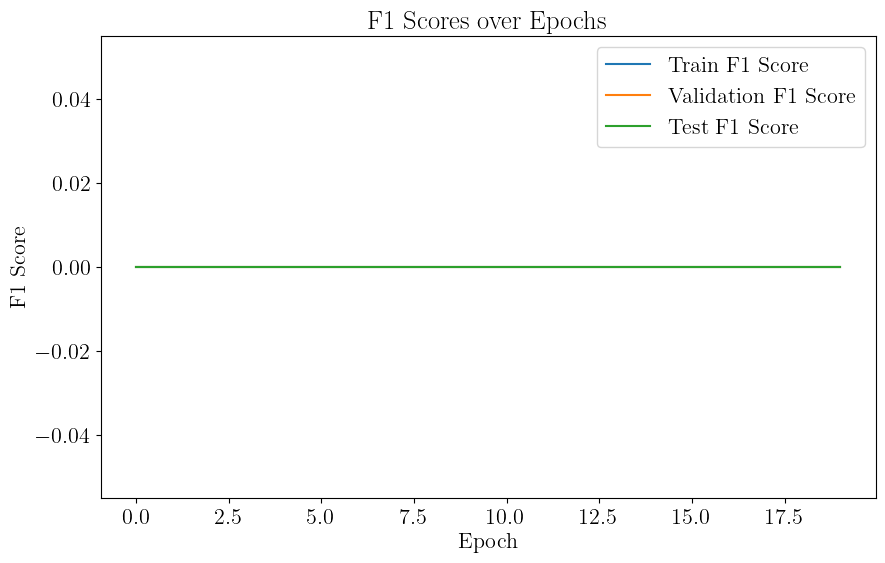

In [34]:
# Plot the F1 scores of last run
plt.figure(figsize=(10, 6))
plt.plot(train_f1_scores, label='Train F1 Score')
plt.plot(val_f1_scores, label='Validation F1 Score')
plt.plot(test_f1_scores, label='Test F1 Score')
# plt.plot(loss_scores, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('F1 Scores over Epochs')
plt.legend()
plt.show()

In [35]:
# for batch in cluster_loader:
#     batch = batch.to(device)
#     print( batch.edge_index.device, batch.prob.device)
    
    #print(batch.edge_index.shape)

In [36]:
import networkx as nx
import matplotlib.pyplot as plt
import torch
import matplotlib.colors as mcolors
from torch_geometric.utils import to_networkx
from torch_geometric.data import Data

In [37]:
torch.where(data.train_mask == True)

(tensor([     0,      2,      3,  ..., 169338, 169339, 169342], device='cuda:0'),)

In [38]:
def count_edges_with_different_labels(data, sampled_edge_index):
    """
    Counts edges with different labels at endpoints in both the original and sampled graphs.
    
    Args:
        data: Data object containing the original graph information.
        sampled_edge_index: Edge index of the sampled subgraph.
    
    Returns:
        A dictionary with counts and percentages of edges with different labels.
    """
    # Original graph edges
    original_edges = data.edge_index
    num_original_edges = original_edges.size(1)
    
    # Count edges with different labels in the original graph
    different_label_edges_original = 0
    for i in range(num_original_edges):
        node1, node2 = original_edges[:, i]
        if data.y[node1].item() != data.y[node2].item():
            different_label_edges_original += 1
    
    # Sampled graph edges
    sampled_edges = sampled_edge_index
    num_sampled_edges = sampled_edges.size(1)

    # Count edges with different labels in the sampled graph
    different_label_edges_sampled = 0
    for i in range(num_sampled_edges):
        node1, node2 = sampled_edges[:, i]
        if data.y[node1].item() != data.y[node2].item():
            different_label_edges_sampled += 1

    # Calculate percentages
    percentage_original = (different_label_edges_original / num_original_edges) * 100 if num_original_edges > 0 else 0
    percentage_sampled = (different_label_edges_sampled / num_sampled_edges) * 100 if num_sampled_edges > 0 else 0

    # Prepare the result
    result = {
        "original_graph": {
            "different_label_edges": different_label_edges_original,
            "total_edges": num_original_edges,
            "percentage": percentage_original
        },
        "sampled_graph": {
            "different_label_edges": different_label_edges_sampled,
            "total_edges": num_sampled_edges,
            "percentage": percentage_sampled
        }
    }

    return result

In [39]:
def plot_full_graph_with_train_nodes(data, train_mask, ax=None):
    """
    Plots the full graph with training nodes highlighted and colored by their labels.
    Args:
        data: Data object containing edge_index, node labels, and other features.
        train_mask: Boolean tensor indicating training nodes.
        ax: Matplotlib axis on which to plot (for side-by-side plotting).
    """
    # Convert PyG data to NetworkX graph for visualization
    G = to_networkx(data)
    
    # Generate color map for each label
    unique_labels = torch.unique(data.y[train_mask]).tolist()
    color_map = {label: color for label, color in zip(unique_labels, mcolors.TABLEAU_COLORS)}

    # Set node colors based on whether they are a training node and their label
    node_colors = [
        color_map[data.y[i].item()] if train_mask[i].item() else 'gray' for i in range(data.num_nodes)
    ]
    
    pos = None
    
    if DATASET_NAME == 'moon':
        pos = {i: (data.x[i][0].item(), data.x[i][1].item()) for i in range(len(data.x))}
    elif pos is None:
        pos = nx.spring_layout(G, seed=42)

    # Plot the full graph with training nodes highlighted by label color
    nx.draw(G, pos, node_color=node_colors, ax=ax, with_labels=False, node_size=100, edge_color="lightblue")
    
    # Add label above each node showing the label value
    for node, p in pos.items():
        label = data.y[node].item()
        ax.text(p[0], p[1] + 0.05, str(label), fontsize=8, ha='center', va='center')
    
    ax.set_title("Full Graph with Training Nodes Highlighted by Label")
    ax.axis("off")
    
    return pos


def plot_sampled_subgraph(data, sampled_edge_index, train_mask, ax=None, pos=None):
    """
    Plots the sampled subgraph based on the edge probability model with training nodes highlighted by label.
    Args:
        data: Data object containing node information.
        sampled_edge_index: Edge index of the sampled subgraph.
        train_mask: Boolean tensor indicating training nodes.
        ax: Matplotlib axis on which to plot (for side-by-side plotting).
    """
    # Convert sampled edges to NetworkX graph
    G_sampled = to_networkx(Data(x = data.x, y = data.y, edge_index = sampled_edge_index))
    
    # Use same color map as the full graph
    unique_labels = torch.unique(data.y[train_mask]).tolist()
    color_map = {label: color for label, color in zip(unique_labels, mcolors.TABLEAU_COLORS)}

    # Use same layout as the full graph for consistent positioning
    if pos is None:
        pos = nx.spring_layout(G_sampled, seed=42)
    
    # Set node colors based on training status and label for nodes in the sampled graph
    node_colors = [
        color_map[data.y[i].item()] if train_mask[i].item() and i in G_sampled.nodes else 'gray'
        for i in G_sampled.nodes
    ]

    # Plot the sampled subgraph with node labels
    nx.draw(G_sampled, pos, node_color=node_colors, ax=ax, with_labels=False, node_size=100, edge_color="orange")
    
    # Add label above each node showing the label value
    for node, p in pos.items():
        label = data.y[node].item()
        ax.text(p[0], p[1] + 0.05, str(label), fontsize=8, ha='center', va='center')
    
    ax.set_title("Sampled Subgraph (Edge Probability Model) with Training Nodes Highlighted by Label")
    ax.axis("off")


def visualize_graphs_side_by_side(data, train_mask, sampled_edge_index, show=True):
    """
    Visualizes the full graph with training nodes and the sampled subgraph side by side, with training nodes colored by label.
    Args:
        data: Data object containing the full graph information.
        train_mask: Boolean tensor indicating training nodes.
        sampled_edge_index: Edge index of the sampled subgraph.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    
    # Plot full graph with training nodes highlighted by label
    pos1 = plot_full_graph_with_train_nodes(data, train_mask, ax=ax1)

    # Plot sampled subgraph with training nodes highlighted by label, using the same layout
    plot_sampled_subgraph(data, sampled_edge_index, train_mask, ax=ax2, pos=pos1)
    
    if show==False:
        plt.close()
    else:
        plt.show()
    
    return fig

# Example Usage:
# Assuming `train_mask` is a boolean mask tensor, and `sampled_edge_index` is the edge index after sampling
# visualize_graphs_side_by_side(data, train_mask=data.train_mask, sampled_edge_index=sampled_edge_index)

In [40]:
def visualize(istest=True, show=True):
    if use_metis == False:
        with torch.no_grad():
            edge_probs = model.edge_prob_mlp(data.x, data.edge_index).squeeze()
            sampled_edge_indices, sampled_edge_weight = gumbel_softmax_sampling(data,
                edge_probs,
                data.edge_index,
                q=sample_size, istest=istest)

            sampled_edge_index = data.edge_index[:, sampled_edge_indices]
            fig = None
            fig = visualize_graphs_side_by_side(data, train_mask=data.train_mask, sampled_edge_index=sampled_edge_index, show=show)

            # Example Usage
            # Assuming `data` is your original graph and `sampled_edge_index` is your sampled edge index
            result = count_edges_with_different_labels(data, sampled_edge_index)

            print("\% of heterophily:")

            # Print the results
            print(f"Original graph: {result['original_graph']['different_label_edges']} edges with different labels "
                  f"out of {result['original_graph']['total_edges']} total edges "
                  f"({result['original_graph']['percentage']:.2f}%).")

            print(f"Sampled graph: {result['sampled_graph']['different_label_edges']} edges with different labels "
                  f"out of {result['sampled_graph']['total_edges']} total edges "
                  f"({result['sampled_graph']['percentage']:.2f}%).")
            
            return fig
            
# fig = visualize(False) #Sampled from the best
# fig = visualize(True)  #Best Sparsifier

In [41]:
# def sample_gumbel(shape, eps=1e-20):
#     """Sample from Gumbel(0, 1)"""
#     U = torch.rand(shape)
#     return -torch.log(-torch.log(U + eps) + eps)

# # Example usage
# shape = (10,)  # Sample 10 values
# gumbel_noise = sample_gumbel(shape)
# print(gumbel_noise)

## Animate the Sparsification

In [42]:
def store_figures_during_test():
    figures = []
    for epoch in range(20):  # Assuming 100 epochs
        fig = visualize(False, False)
        figures.append(fig)
        plt.close(fig)
    return figures

# figures = store_figures_during_test()

In [43]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def create_animation_from_figures(figures):
    fig_anim, ax_anim = plt.subplots()

    def update_fig(i):
        ax_anim.clear()
        figures[i].canvas.draw()
        img_array = np.frombuffer(figures[i].canvas.tostring_rgb(), dtype=np.uint8)
        img_array = img_array.reshape(figures[i].canvas.get_width_height()[::-1] + (3,))
        ax_anim.imshow(img_array)
        ax_anim.axis('off')

    ani = animation.FuncAnimation(fig_anim, update_fig, frames=len(figures), interval=200, blit=False)

    from IPython.display import HTML
    return HTML(ani.to_jshtml())

# # Example Usage:
# # Assuming `figures` is a list of stored figure objects from `store_figures_during_training`.
# animation_html = create_animation_from_figures(figures)
# display(animation_html)

In [44]:
if figure_log:
    animation_html = create_animation_from_figures(train_figures)
    display(animation_html)

## Scratch

In [45]:
# from torch_geometric.data import Data

# x = torch.Tensor([[1,0],[1,0],[1,0],[0,1],[0,1],[0,1],[0,1]])
# y = torch.LongTensor([0,0,0, 1, 1, 1, 1])
# edge_index = torch.LongTensor([[1,2],[1,4],[1,5],[2,1],[3,6],[3,7],[4,5],[4,1],[4,6],[4,7],[5,1],[5,4],[5,6],[6,3],[6,4],[6,5],[6,7],[7,3],[7,4],[7,6]]).T
# # edge_index = torch.LongTensor([[1,2]]).T


# edge_index = edge_index-1
# data = Data(x=x, y=y, edge_index = edge_index)
# data

## Reconstruct graph from embeddings


In [46]:
# model

In [47]:
# data

In [48]:
# H = model(data, data.edge_index)
# H.shape

In [49]:
# # Step 1: Compute cosine similarity matrix
# def create_cosine_similarity_graph(H, alpha=0.5):
#     # Normalize the features
#     H_norm = F.normalize(H, p=2, dim=1)
    
#     # Compute cosine similarity
#     cos_sim = torch.mm(H_norm, H_norm.t())
    
#     # Create edge_index from similarity matrix
#     mask = (cos_sim > alpha) & (torch.eye(len(H), device=H.device) == 0)
#     edge_index = torch.nonzero(mask).t()
    
#     return edge_index

# # Create new graph
# new_edge_index = create_cosine_similarity_graph(H, alpha=0.998)

# # Step 2: Compare with original graph
# def compare_graphs(new_edge_index, original_edge_index, y):
#     # Convert edge indices to sets of tuples for comparison
#     new_edges = set([(u.item(), v.item()) for u, v in new_edge_index.t()])
#     original_edges = set([(u.item(), v.item()) for u, v in original_edge_index.t()])
    
#     # Total edges in constructed graph
#     total_new_edges = len(new_edges)
    
#     # Overlapped edges
#     overlapped_edges = new_edges & original_edges
#     num_overlapped = len(overlapped_edges)
    
#     # Overlapped edges with same label
#     same_label_count = 0
#     for u, v in overlapped_edges:
#         if y[u] == y[v]:
#             same_label_count += 1
    
#     # Edge homophily of original graph
#     original_same_label = 0
#     for u, v in original_edges:
#         if y[u] == y[v]:
#             original_same_label += 1
#     original_homophily = original_same_label / len(original_edges)
    
#     return {
#         'total_new_edges': total_new_edges,
#         'num_overlapped': num_overlapped,
#         'same_label_overlapped': same_label_count,
#         'original_homophily': original_homophily
#     }

# # Assuming data is your original graph data
# results = compare_graphs(new_edge_index, data.edge_index, data.y)

# # Print results
# print(f"Total number of edges in constructed graph: {results['total_new_edges']}")
# print(f"Number of overlapped edges with original graph: {results['num_overlapped']}")
# print(f"Number of overlapped edges with same label in both endpoint: {results['same_label_overlapped']}")
# print(f"Edge homophily of original graph: {results['original_homophily']:.4f}")

In [50]:
data

Data(x=[169343, 128], edge_index=[2, 2315598], y=[169343], train_mask=[169343], val_mask=[169343], test_mask=[169343], prob=[2315598], deg_in=[169343], deg_out=[169343])